In [6]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import mediapy as media
from ik_tester.test import test_fig8
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# Configuration
max_vels = [0.01, 0.05, 0.1]
traj_planes = ["xy", "yz", "xz"]
radius = 0.3

# Collect all test results
results = {}  # {(plane, vel): (ref, exec, frames)}
for plane in traj_planes:
    for vel in max_vels:
        print(f"Testing for plane={plane}, max_vel={vel}")
        ref, exec, frames = test_fig8(traj_plane=plane, max_track_vel=vel)
        results[(plane, vel)] = (ref, exec, frames)
        

Testing for plane=xy, max_vel=0.01


Testing for plane=xy, max_vel=0.05


Testing for plane=xy, max_vel=0.1


Testing for plane=yz, max_vel=0.01


Testing for plane=yz, max_vel=0.05


Testing for plane=yz, max_vel=0.1


Testing for plane=xz, max_vel=0.01


Testing for plane=xz, max_vel=0.05


Testing for plane=xz, max_vel=0.1


In [7]:
videos = [frames for (_, _), (_, _, frames) in results.items()]
# Parameters for the grid
rows = len(traj_planes)
cols = len(max_vels)

# Make a 2D grid of frames for each time step
n_frames = min(len(v) for v in videos)  # truncate to shortest
grid_frames = []

for t in range(n_frames):
    row_frames = []
    for r in range(rows):
        col_frames = []
        for c in range(cols):
            idx = r*cols + c
            col_frames.append(videos[idx][t])
        # Concatenate horizontally for this row
        row_frames.append(np.hstack(col_frames))
    # Concatenate vertically for all rows
    grid_frame = np.vstack(row_frames)
    grid_frames.append(grid_frame)

# Display in notebook
media.show_video(grid_frames, fps=60)

This browser does not support the video tag.


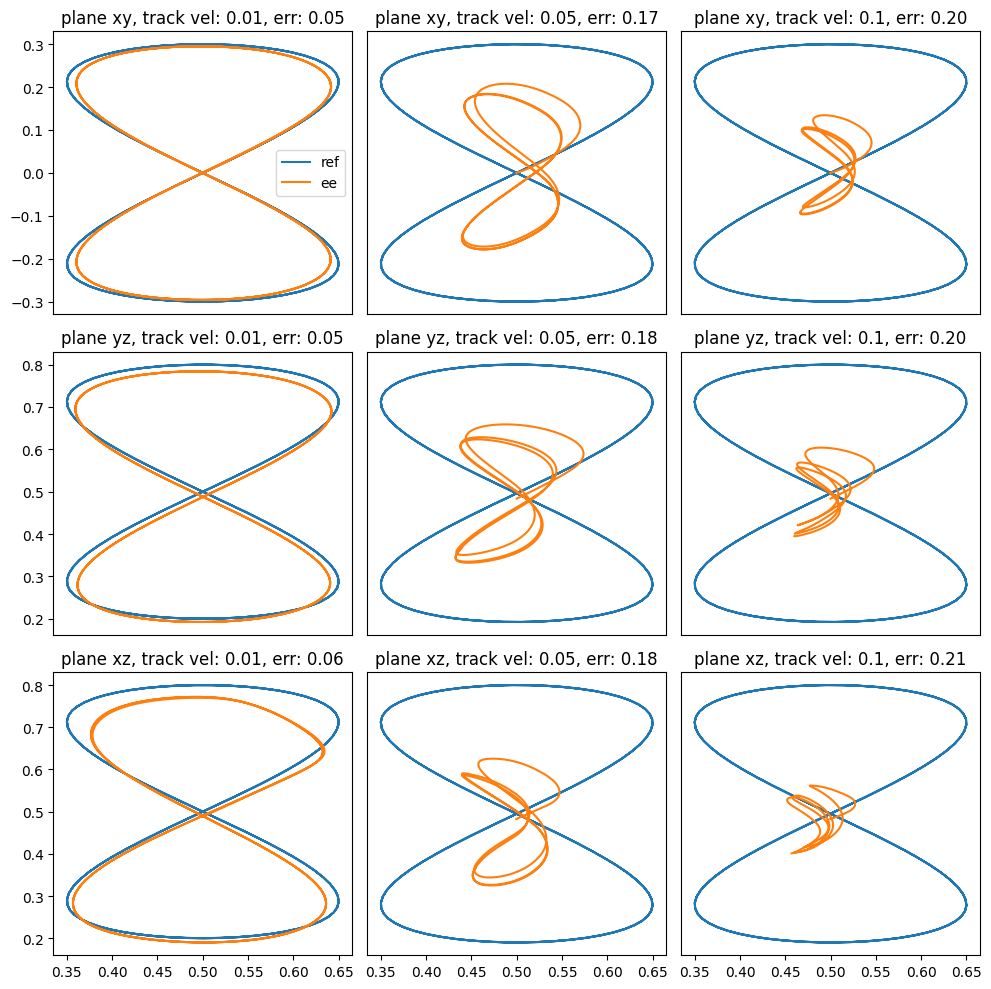

In [ ]:
fig, ax = plt.subplots(3, 3, sharex=False, sharey=False, figsize=(10, 10))

for r, plane in enumerate(traj_planes):
    for c, vel in enumerate(max_vels):
        ref, exec, _ = results[plane, vel]

        errors = np.linalg.norm(ref - exec, axis=1)  # shape (N,)
        mean_err = np.mean(errors)

        ax[r, c].set_title(f"plane {plane}, track vel: {vel}, err: {mean_err:0.2f}")

        # Plot the trajectories
        if plane == "xy":
            ax[r, c].plot(ref[:, 0], ref[:, 1], label="ref")
            ax[r, c].plot(exec[:, 0], exec[:, 1], label="ee")
        elif plane == "yz":
            ax[r, c].plot(ref[:, 1], ref[:, 2], label="ref")
            ax[r, c].plot(exec[:, 1], exec[:, 2], label="ee")
        elif plane == "xz":
            ax[r, c].plot(ref[:, 0], ref[:, 2], label="ref")
            ax[r, c].plot(exec[:, 0], exec[:, 2], label="ee")

        # Hide x-ticks for all but last row
        if r < len(traj_planes) - 1:
            ax[r, c].set_xticks([])
        # Hide y-ticks for all but first column
        if c > 0:
            ax[r, c].set_yticks([])

# Optional: add a legend only once
ax[0,0].legend()
plt.tight_layout()
plt.savefig("readme_assets/plot.svg")                 
